## 1. Project Title & Objective

# Store Sales Prediction

## Project Objective

The objective of this project is to predict daily sales for retail stores using historical sales data, store characteristics, promotions, holidays, competition information, and calendar-based features.

The project follows a forecasting-oriented machine learning workflow, including exploratory data analysis, feature engineering, chronological validation, model training, evaluation, and generation of predictions for unseen test data.

### Business Problem

Accurate sales forecasts can help retailers with inventory planning, staffing, promotional planning, and operational decision-making.

### Project Approach

* Explore historical sales patterns
* Analyze promotions, holidays, store characteristics, and competition
* Engineer calendar and competition-related features
* Use a chronological train-validation split
* Train a gradient boosting regression model
* Evaluate predictions using MAE and RMSE
* Generate sales predictions for the test dataset
* Create a submission file


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import zipfile

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/store_sales")

In [4]:
import os

os.listdir("/content/store_sales")

['store.csv', 'test.csv', 'train.csv']

## 3. Load Datasets

In [5]:
train= pd.read_csv("/content/store_sales/train.csv")
test=pd.read_csv("/content/store_sales/test.csv")
store=pd.read_csv("/content/store_sales/store.csv")

/tmp/ipykernel_907/406014051.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train= pd.read_csv("/content/store_sales/train.csv")


## 4. Initial Data Understanding

shapes

In [6]:
train.shape


(1017209, 9)

In [7]:
test.shape

(41088, 8)

In [8]:
store.shape

(1115, 10)

head

In [9]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [10]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [11]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


describe

In [12]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [13]:

test.describe()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000


In [14]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


null values

## 5. Data Cleaning & Preparation

In [15]:
train.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [16]:
test.isnull().sum()

,0
Id,0
Store,0
DayOfWeek,0
Date,0
Open,11
Promo,0
StateHoliday,0
SchoolHoliday,0


In [17]:


store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


important rules an learnings

select target




in train sales in target and in test sales is absent so id is used to predict sales

phase1 understandig train dataset

how mny stores have open=0 , and how many=1

### 6.1 Train Dataset EDA - Open/Closed Stores

In [18]:
train[train['Open']==0].value_counts()

Store  DayOfWeek  Date        Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday
1115   7          2015-07-26  0      0          0     0      0             0                1
                  2015-04-05  0      0          0     0      0             1                1
                  2015-03-29  0      0          0     0      0             0                1
                  2015-03-22  0      0          0     0      0             0                1
                  2015-03-15  0      0          0     0      0             0                1
                                                                                           ..
1      1          2015-05-25  0      0          0     0      a             0                1
                  2015-04-06  0      0          0     0      b             1                1
                  2014-06-09  0      0          0     0      a             0                1
                  2014-04-21  0      0          0     0      b             1                1
                  2013-05-20  0      0          0     0      a             0                1
Name: count, Length: 172817, dtype: int64

In [19]:

train[train['Open']==0].value_counts().sum()

np.int64(172817)

0: No public holiday
a: Public holiday (e.g., national holiday)
b: Easter holiday
c: Christmas
so when store was closed there were no sales , no customers, no promo

In [20]:
train[train['Open']==1].value_counts()

Store  DayOfWeek  Date        Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday
1115   6          2015-07-25  6897   478        1     0      0             0                1
1      1          2013-01-07  7176   785        1     1      0             1                1
                  2013-01-14  4717   616        1     0      0             0                1
                  2013-01-21  5394   607        1     1      0             0                1
                  2013-01-28  4055   549        1     0      0             0                1
                                                                                           ..
                  2013-04-08  6046   695        1     1      0             0                1
                  2013-03-25  6729   777        1     1      0             1                1
                  2013-03-18  7072   778        1     1      0             0                1
                  2013-03-11  4949   618        1     0      0             0                1
                  2013-03-04  7675   840        1     1      0             0                1
Name: count, Length: 844392, dtype: int64

In [21]:
train[train['Open']==1].value_counts().sum()

np.int64(844392)

this shows sales occured every open day but promotion wa missing over some days

In [22]:

train[train['Promo']==0].value_counts().sum()

np.int64(629129)

In [23]:
train[train['Promo']==1].value_counts().sum()

np.int64(388080)

In [24]:
train[train['Promo']==0].value_counts()

Store  DayOfWeek  Date        Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday
1115   7          2015-07-26  0      0          0     0      0             0                1
1      1          2013-01-14  4717   616        1     0      0             0                1
                  2013-01-28  4055   549        1     0      0             0                1
                  2013-02-11  4409   599        1     0      0             0                1
                  2013-02-25  4038   534        1     0      0             0                1
                                                                                           ..
                  2013-08-05  4086   522        1     0      0             1                1
                  2013-07-22  4149   493        1     0      0             1                1
                  2013-07-08  4475   523        1     0      0             1                1
                  2013-06-24  3549   494        1     0      0             0                1
                  2013-06-10  4291   531        1     0      0             0                1
Name: count, Length: 629129, dtype: int64

In [25]:
train[train['Promo']==1].value_counts()

Store  DayOfWeek  Date        Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday
1115   5          2015-01-09  7498   480        1     1      0             1                1
                  2014-12-19  11673  646        1     1      0             0                1
                  2014-12-05  10636  625        1     1      0             0                1
                  2014-11-28  10435  598        1     1      0             0                1
                  2014-11-14  6623   442        1     1      0             0                1
                                                                                           ..
1      1          2013-03-04  7675   840        1     1      0             0                1
                  2013-02-18  6407   710        1     1      0             0                1
                  2013-02-04  7032   762        1     1      0             0                1
                  2013-01-21  5394   607        1     1      0             0                1
                  2013-01-07  7176   785        1     1      0             1                1
Name: count, Length: 388080, dtype: int64

In [26]:


inconsistent_sales_open = train[(train['Sales'] == 0) & (train['Open'] == 1)]


if not inconsistent_sales_open.empty:
    print("Rows where Sales are 0 but Open is 1 (inconsistent data):")
    print(inconsistent_sales_open)
else:
    print("No rows found where Sales are 0 and Open is 1, which is good!")



Rows where Sales are 0 but Open is 1 (inconsistent data):
        Store  DayOfWeek        Date  Sales  Customers  Open  Promo  \
86825     971          5  2015-05-15      0          0     1      0   
142278    674          4  2015-03-26      0          0     1      0   
196938    699          4  2015-02-05      0          0     1      1   
322053    708          3  2014-10-01      0          0     1      1   
330176    357          1  2014-09-22      0          0     1      0   
340348    227          4  2014-09-11      0          0     1      0   
340860    835          4  2014-09-11      0          0     1      0   
341795    835          3  2014-09-10      0          0     1      0   
346232    548          5  2014-09-05      0          0     1      1   
346734     28          4  2014-09-04      0          0     1      1   
347669     28          3  2014-09-03      0          0     1      1   
348604     28          2  2014-09-02      0          0     1      1   
386065    102      

In [27]:
train[(train['Sales']==0)&(train['Open']==1)].value_counts()

Store  DayOfWeek  Date        Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday
25     3          2014-02-12  0      0          1     0      0             0                1
       4          2014-02-13  0      0          1     0      0             0                1
28     2          2014-09-02  0      0          1     1      0             1                1
       3          2014-09-03  0      0          1     1      0             1                1
       4          2014-09-04  0      0          1     1      0             0                1
57     2          2014-07-01  0      0          1     1      0             0                1
102    4          2014-07-24  0      0          1     0      0             1                1
       6          2014-07-12  0      0          1     0      0             0                1
227    4          2014-09-11  0      0          1     0      0             0                1
232    4          2013-01-24  0      0          1     1      0             0                1
238    4          2014-07-24  0      0          1     0      0             1                1
259    4          2013-02-07  0      0          1     1      0             0                1
303    4          2014-07-24  0      0          1     0      0             1                1
327    3          2014-03-12  0      0          1     0      0             0                1
339    3          2013-01-30  0      0          1     0      0             0                1
       4          2013-01-31  0      0          1     0      0             0                1
353    6          2013-03-16  0      0          1     0      0             0                1
357    1          2014-09-22  0      0          1     0      0             0                1
364    2          2013-05-07  0      0          1     0      0             0                1
       3          2013-05-08  0      0          1     0      0             0                1
387    4          2014-07-24  0      0          1     0      0             1                1
391    3          2013-08-28  0      0          1     1      0             1                1
548    5          2014-09-05  0      0          1     1      0             1                1
589    1          2013-04-29  0      0          1     1      0             0                1
623    5          2014-01-24  0      0          1     1      0             0                1
       6          2014-01-25  0      0          1     0      0             0                1
661    5          2014-04-04  0      0          1     1      0             0                1
663    1          2013-09-02  0      0          1     0      0             1                1
665    5          2013-06-28  0      0          1     0      0             0                1
       6          2013-06-29  0      0          1     0      0             0                1
674    4          2015-03-26  0      0          1     0      0             0                1
681    5          2013-05-10  0      0          1     0      0             0                1
699    4          2015-02-05  0      0          1     1      0             0                1
700    3          2013-06-05  0      0          1     1      0             0                1
708    3          2014-10-01  0      0          1     1      0             0                1
762    4          2013-01-17  0      0          1     0      0             0                1
835    3          2014-09-10  0      0          1     0      0             0                1
       4          2014-09-11  0      0          1     0      0             0                1
850    6          2014-03-29  0      0          1     0      0             0                1
882    3          2014-07-23  0      0          1     0      0             1                1
887    3          2014-07-23  0      0          1     0      0             0                1
925    4          2014-07-03  0      0          1     1  

 sales is =0 open=1 nd customersalso=0 we have 54 evidences of this pattern but with one exception

does having promotion apper to be any connection with sales

### 6.2 Train Dataset EDA - Promotions

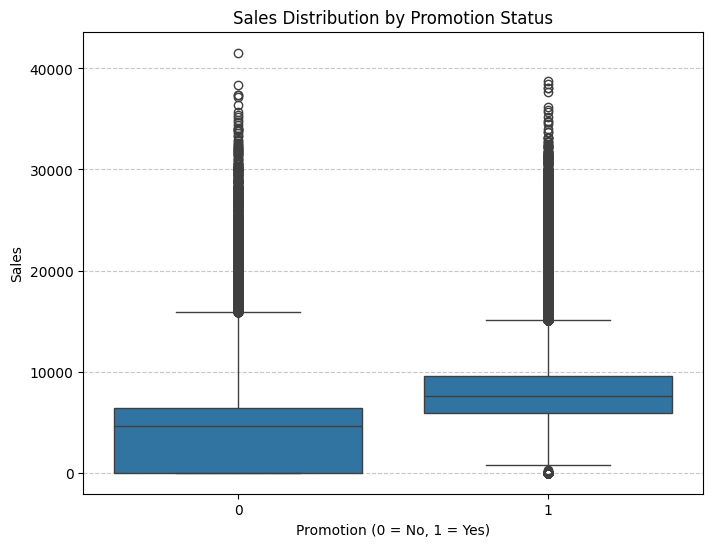

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Promo', y='Sales', data=train)
plt.title('Sales Distribution by Promotion Status')
plt.xlabel('Promotion (0 = No, 1 = Yes)')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
# Calculate average sales for promoted and non-promoted days
average_sales_promo = train.groupby('Promo')['Sales'].mean().reset_index()

print("Average Sales by Promotion Status:")
print(average_sales_promo)

# For a more detailed numerical comparison, including standard deviation, median, etc.
print("\nDescriptive Statistics of Sales by Promotion Status:")
print(train.groupby('Promo')['Sales'].describe())

Average Sales by Promotion Status:
   Promo        Sales
0      0  4406.050805
1      1  7991.152046

Descriptive Statistics of Sales by Promotion Status:
          count         mean          std  min     25%     50%     75%  \
Promo                                                                    
0      629129.0  4406.050805  3442.450020  0.0     0.0  4622.0  6367.0   
1      388080.0  7991.152046  3419.025495  0.0  5922.0  7553.0  9603.0   

           max  
Promo           
0      41551.0  
1      38722.0  


This numerical evidence, combined with the visual evidence from the box plot, strongly refutes the idea that 'promotion is not necessarily connected with sales'. Instead, it shows a robust positive correlation: promotions lead to a substantial increase in sales.

so open=sales
promo= sales, now,
days of week?

does sales differ depending on days of week?


### 6.3 Train Dataset EDA - Days of Week

In [30]:
train.groupby('DayOfWeek')['Sales'].mean()

,Sales
DayOfWeek,
1,7809.044510
2,7005.244467
3,6555.884138
4,6247.575913
5,6723.274305
6,5847.562599
7,204.183189


in all days of week sales are higher except 7 , it is probablly sunday which is dramitically low

In [31]:
train.groupby("DayOfWeek")["Open"].mean()

,Open
DayOfWeek,
1,0.950459
2,0.988309
3,0.974400
4,0.923199
5,0.950598
6,0.995357
7,0.024826


Sales differ substantially across days in the raw data, and the very low Day 7 average is largely associated with stores being closed on that day."

In [32]:
train[train['Open'] == 1].groupby('DayOfWeek')['Sales'].mean()

,Sales
DayOfWeek,
1,8216.073074
2,7088.113656
3,6728.122978
4,6767.310159
5,7072.677012
6,5874.840238
7,8224.723908


In [33]:
train[train['Open'] == 1].groupby('DayOfWeek')['Promo'].mean()

,Promo
DayOfWeek,
1,0.561522
2,0.535687
3,0.537263
4,0.550511
5,0.520449
6,0.000000
7,0.000000


In [34]:
train[train['Open'] == 1].groupby('DayOfWeek')['Customers'].mean()

,Customers
DayOfWeek,
1,855.444984
2,769.986753
3,740.598876
4,755.569784
5,781.771639
6,660.177526
7,1441.532424


sales per customer

In [35]:
train_open = train[train['Open'] == 1].copy()
train_open['SalesPerCustomer'] = train_open['Sales'] / train_open['Customers']

# Display the first few rows with the new column
display(train_open[['Sales', 'Customers', 'SalesPerCustomer']].head())

,Sales,Customers,SalesPerCustomer
0,5263,555,9.482883
1,6064,625,9.702400
2,8314,821,10.126675
3,13995,1498,9.342457
4,4822,559,8.626118


In [36]:
sales_per_customer_per_day = train_open.groupby('DayOfWeek')['SalesPerCustomer'].mean()
display(sales_per_customer_per_day)

,SalesPerCustomer
DayOfWeek,
1,9.896977
2,9.594422
3,9.496812
4,9.358152
5,9.438295
6,9.260104
7,6.458913


in analyzing days of week we analyzed that in raw data , sunday has lowest sales, than we found that at sunday most shopes are closed, then when we filtered open shopes we witnessed tat sunday has highest sales , but promotions are not highest like that, day 7 has dramatically higher customer traffic but sales per customer are not higher

**State Holidays**

### 6.4 Train Dataset EDA - State Holidays

In [37]:

train['StateHoliday'].value_counts()

,count
StateHoliday,
0,855087
0,131072
a,20260
b,6690
c,4100


In [38]:
train['StateHoliday'].dtype

dtype('O')

In [39]:
train['StateHoliday'].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [40]:
train['StateHoliday'] = train['StateHoliday'].astype(str)

In [41]:
train['StateHoliday'].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [42]:
train.groupby('StateHoliday')['Sales'].mean()

,Sales
StateHoliday,
0,5947.483893
a,290.735686
b,214.311510
c,168.733171


In [43]:
train.groupby('StateHoliday')['Open'].mean()

,Open
StateHoliday,
0,0.855320
a,0.034255
b,0.021674
c,0.017317


In [44]:
train[train['Open'] == 1].groupby('StateHoliday')['Sales'].mean()

,Sales
StateHoliday,
0,6953.515034
a,8487.471182
b,9887.889655
c,9743.746479


State holidays are strongly associated with store closures, with fewer than 4% of observations open on holiday categories. Consequently, raw sales are much lower on state holidays. Among the stores that remained open, average sales were higher than on non-holiday days; however, these results are based on relatively few open observations and should therefore be interpreted cautiously.

school holiday

### 6.5 Train Dataset EDA - School Holidays

In [45]:
train['SchoolHoliday'].value_counts()

,count
SchoolHoliday,
0,835488
1,181721


In [46]:


train.groupby('SchoolHoliday')['Sales'].mean()

,Sales
SchoolHoliday,
0,5620.979034
1,6476.522207


In [47]:
train[train['Open'] == 1].groupby('SchoolHoliday')['Sales'].mean()

,Sales
SchoolHoliday,
0,6896.782411
1,7200.181650


In [48]:
train.groupby('DayOfWeek')['SchoolHoliday'].mean()

,SchoolHoliday
DayOfWeek,
1,0.235335
2,0.251229
3,0.237778
4,0.238246
5,0.248449
6,0.018821
7,0.018821


School holidays are associated with somewhat higher average sales. The difference remains after restricting the analysis to open stores, but school holidays occur predominantly on weekdays, and sales also vary considerably by day of week. Therefore, the observed difference should not be interpreted as a causal effect of school holidays.

date

### 6.6 Train Dataset EDA - Date and Seasonality

In [49]:

train['Date'].describe()

,Date
count,1017209
unique,942
top,2013-01-02
freq,1115


In [50]:
train['Date'].value_counts()

,count
Date,
2013-01-02,1115
2015-07-31,1115
2015-07-30,1115
2015-07-29,1115
2015-07-28,1115
...,...
2014-12-28,935
2014-12-26,935
2014-12-25,935


In [51]:
train['Date'] = pd.to_datetime(train['Date'])

In [52]:
train['Date'].min(), train['Date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [53]:
train[train['Open']==0]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
291,292,5,2015-07-31,0,0,0,1,0,1
875,876,5,2015-07-31,0,0,0,1,0,1
1406,292,4,2015-07-30,0,0,0,1,0,1
1990,876,4,2015-07-30,0,0,0,1,0,1
2521,292,3,2015-07-29,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [54]:
monthly_sales = train.resample('ME', on='Date')['Sales'].mean()
monthly_sales

,Sales
Date,
2013-01-31,5211.555578
2013-02-28,5494.371397
2013-03-31,5820.349168
2013-04-30,5483.749836
2013-05-31,5364.127383
2013-06-30,5402.162960
2013-07-31,6042.062260
2013-08-31,5729.574049
2013-09-30,5322.988430


<Axes: title={'center': 'Monthly Average Sales'}, xlabel='Date'>

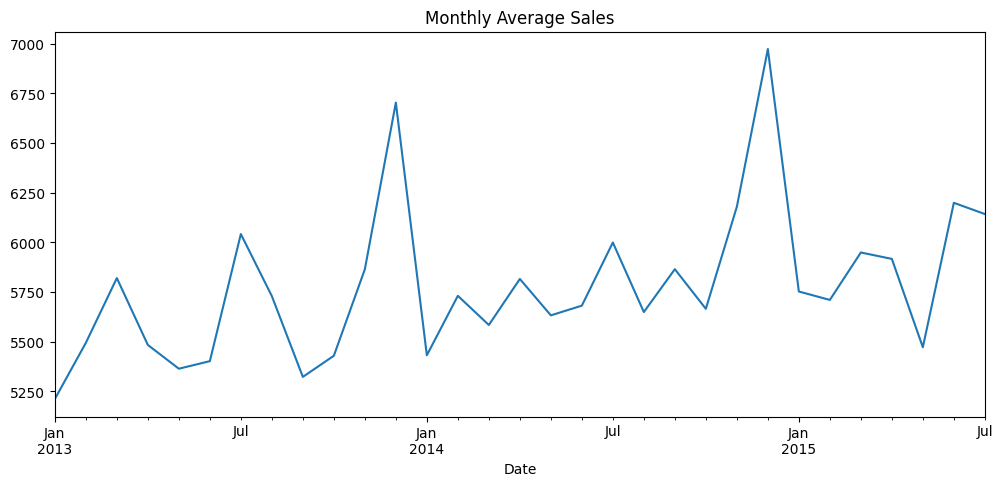

In [55]:
monthly_sales.plot(figsize=(12,5), title='Monthly Average Sales')

sales fluctuate over time rather than showing a steady upward or downward trend.

December is the highest month in both complete years. That's a strong clue that there may be recurring seasonal behavior around the end of the year.

Correct that 2014 generally appears somewhat higher than 2013, particularly toward the end of the year.

average sales by year and also visulize it

In [56]:
average_sales_by_year = train.groupby(train['Date'].dt.year)['Sales'].mean()
display(average_sales_by_year)

,Sales
Date,
2013,5658.533675
2014,5833.290704
2015,5878.245380


<Axes: title={'center': 'yearly Average Sales'}, xlabel='Date'>

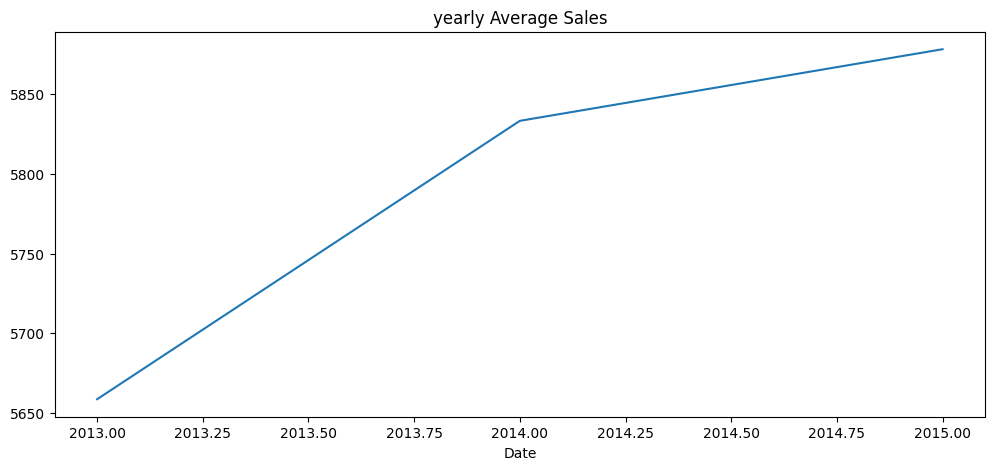

In [57]:
average_sales_by_year.plot(figsize=(12,5), title='yearly Average Sales')

Average sales increased from 2013 to 2014. The available 2015 data also has a higher average, but 2015 contains only January–July, so a direct full-year comparison is not appropriate. Overall, the data suggests modest growth alongside substantial month-to-month fluctuations.

In [58]:
monthly_open_sales = train[train['Open'] == 1].resample('ME', on='Date')['Sales'].mean()

monthly_open_sales

,Sales
Date,
2013-01-31,6239.641380
2013-02-28,6428.597796
2013-03-31,7212.834110
2013-04-30,6579.319656
2013-05-31,7076.217960
2013-06-30,6467.051428
2013-07-31,6923.154611
2013-08-31,6595.927627
2013-09-30,6363.388121


<Axes: title={'center': 'Monthly Average Sales — Open Stores Only'}, xlabel='Date'>

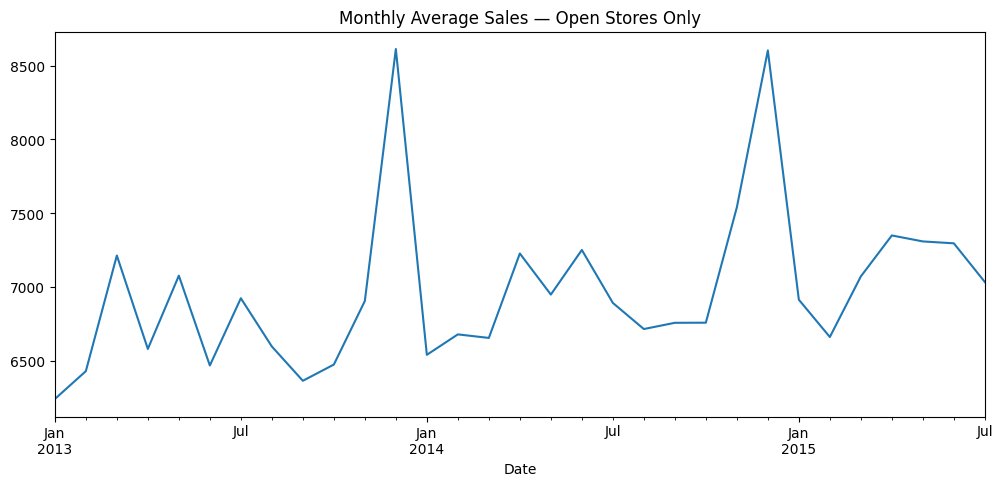

In [59]:
monthly_open_sales.plot(
    figsize=(12,5),
    title='Monthly Average Sales — Open Stores Only'
)

Date → month → group by month → average Sales

In [60]:
train.groupby(train['Date'].dt.month)['Sales'].mean()

,Sales
Date,
1,5465.395529
2,5645.253150
3,5784.578871
4,5738.866916
5,5489.639973
6,5760.964375
7,6064.915711
8,5693.016554
9,5570.246033


In [61]:
train[train['Open'] == 1].groupby(train['Date'].dt.month)['Sales'].mean()

,Sales
Date,
1,6563.690444
2,6589.165535
3,6976.412026
4,7046.228420
5,7106.453154
6,7000.978190
7,6952.682125
8,6648.984654
9,6546.343035


Sales exhibit a recurring monthly seasonal pattern. December has the highest average sales among open stores, while sales are generally lower during several early- and late-summer months. This suggests that month/season is an important factor to consider when forecasting sales.

does customer visit correpond higher or lower sales

### 6.7 Train Dataset EDA - Customer Traffic

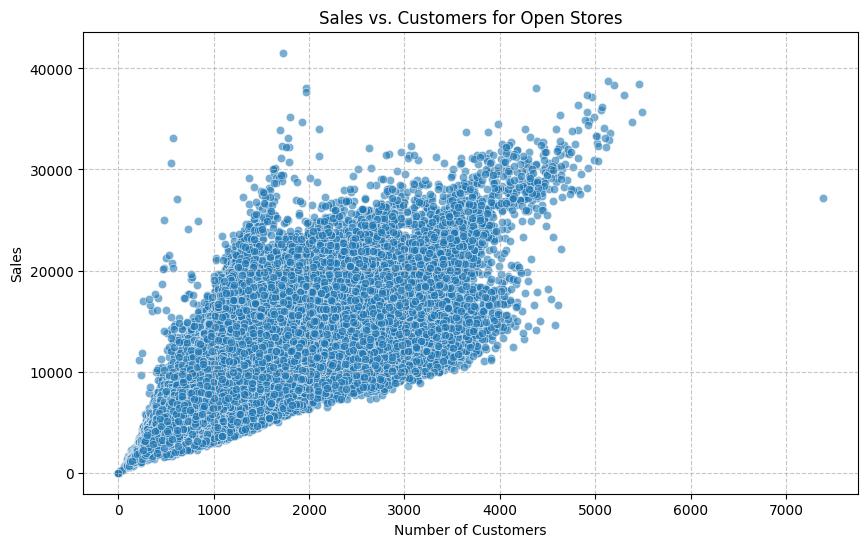

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Customers', y='Sales', data=train_open, alpha=0.6)
plt.title('Sales vs. Customers for Open Stores')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [63]:
# Calculate the correlation between 'Customers' and 'Sales' for open stores
correlation = train_open['Customers'].corr(train_open['Sales'])
print(f"Correlation between Customers and Sales (Open Stores): {correlation:.2f}")

Correlation between Customers and Sales (Open Stores): 0.82


Sales distribution and outliers

### 6.8 Train Dataset EDA - Sales Distribution and Outliers

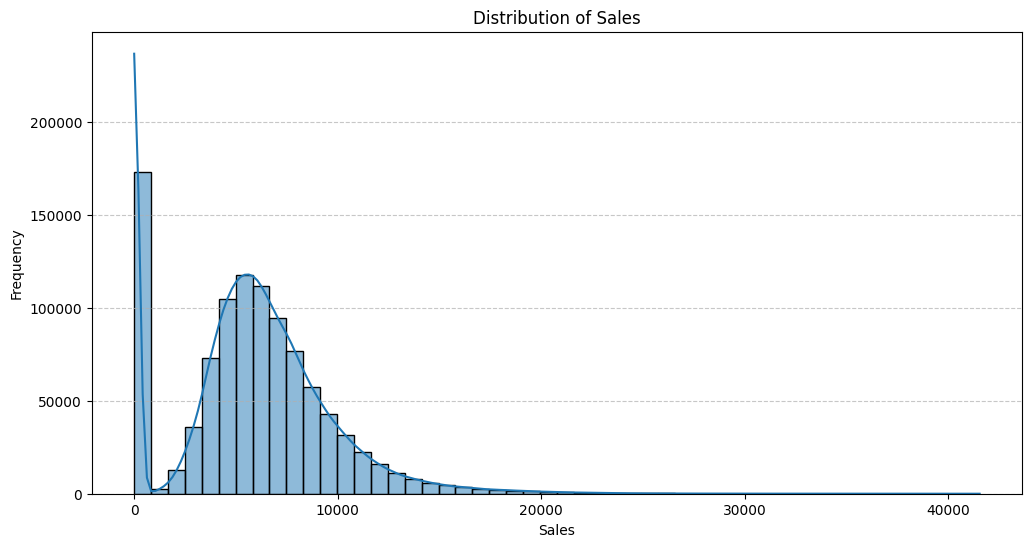

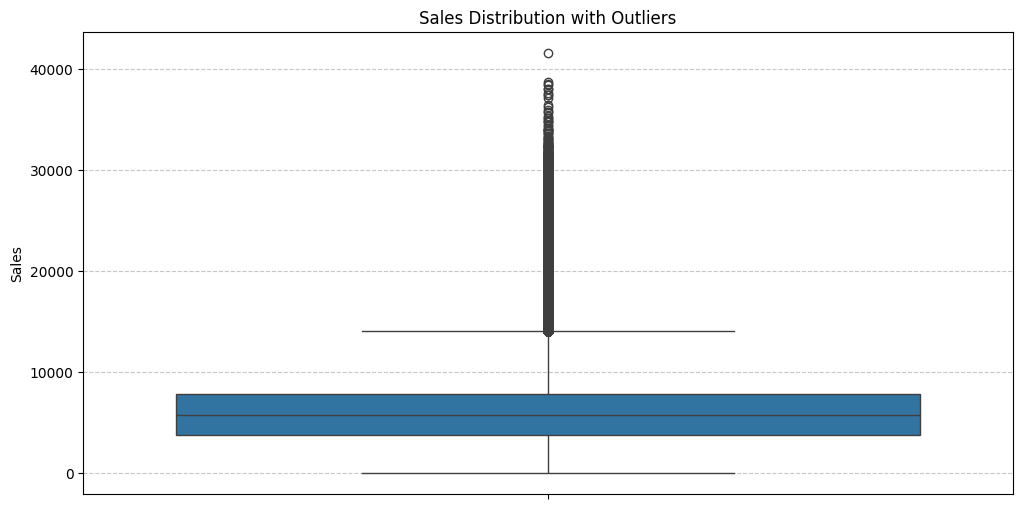

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Sales Distribution
plt.figure(figsize=(12, 6))
sns.histplot(train['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box plot for Sales Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(y=train['Sales'])
plt.title('Sales Distribution with Outliers')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [65]:
sales_description = train['Sales'].describe()
display(sales_description)

# Calculate Q1, Q3, and IQR for outlier detection
Q1 = sales_description['25%']
Q3 = sales_description['75%']
IQR = Q3 - Q1

# Define bounds for outliers
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"\nInterquartile Range (IQR): {IQR:.2f}")
print(f"Upper bound for outliers: {upper_bound:.2f}")
print(f"Lower bound for outliers: {lower_bound:.2f}")

# Count the number of outliers
outliers = train[(train['Sales'] < lower_bound) | (train['Sales'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(train) * 100:.2f}%")

,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04



Interquartile Range (IQR): 4129.00
Upper bound for outliers: 14049.50
Lower bound for outliers: -2466.50
Number of outliers: 26694
Percentage of outliers: 2.62%


In [66]:
high_sales = train[train['Sales'] > 14049.50]

high_sales['Customers'].describe()

,Customers
count,26694.000000
mean,1987.052708
std,748.321174
min,261.000000
25%,1422.000000
50%,1834.000000
75%,2346.000000
max,7388.000000


Sales values above the IQR outlier threshold are associated with substantially higher customer traffic. Therefore, these observations should not automatically be treated as erroneous outliers. They may represent genuinely high-demand store-days and could contain useful information for sales prediction.

Of those 54 open stores with zero sales, what are their Customers, Promo, and StateHoliday values?

In [67]:
display(inconsistent_sales_open[['Customers', 'Promo', 'StateHoliday']])

,Customers,Promo,StateHoliday
86825,0,0,0
142278,0,0,0
196938,0,1,0
322053,0,1,0
330176,0,0,0
340348,0,0,0
340860,0,0,0
341795,0,0,0
346232,0,1,0
346734,0,1,0


A small number of observations have zero sales despite the store being marked open. Most of these also have zero customers, while only two records show a small number of customers. These observations may represent unusual operational or data-recording situations and should be retained for now rather than automatically removed.

store_level-sales

### 6.9 Train Dataset EDA - Store-Level Sales

In [68]:
store_sales = train.groupby('Store')['Sales'].mean().reset_index()
display(store_sales.head())

,Store,Sales
0,1,3945.704883
1,2,4122.991507
2,3,5741.253715
3,4,8021.769639
4,5,3867.110403


In [69]:
print(store_sales['Sales'].describe())

count     1115.000000
mean      5763.320541
std       2046.447377
min       2244.503185
25%       4412.415567
50%       5459.185775
75%       6633.871550
max      20718.515924
Name: Sales, dtype: float64


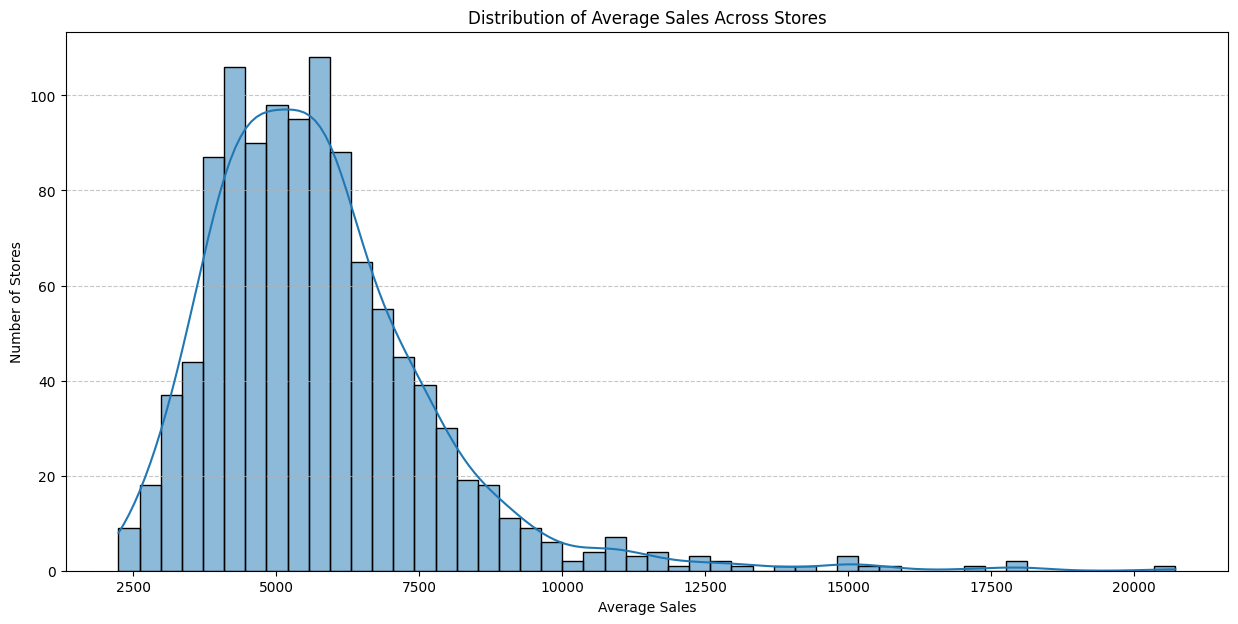

In [70]:
plt.figure(figsize=(15, 7))
sns.histplot(store_sales['Sales'], bins=50, kde=True)
plt.title('Distribution of Average Sales Across Stores')
plt.xlabel('Average Sales')
plt.ylabel('Number of Stores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

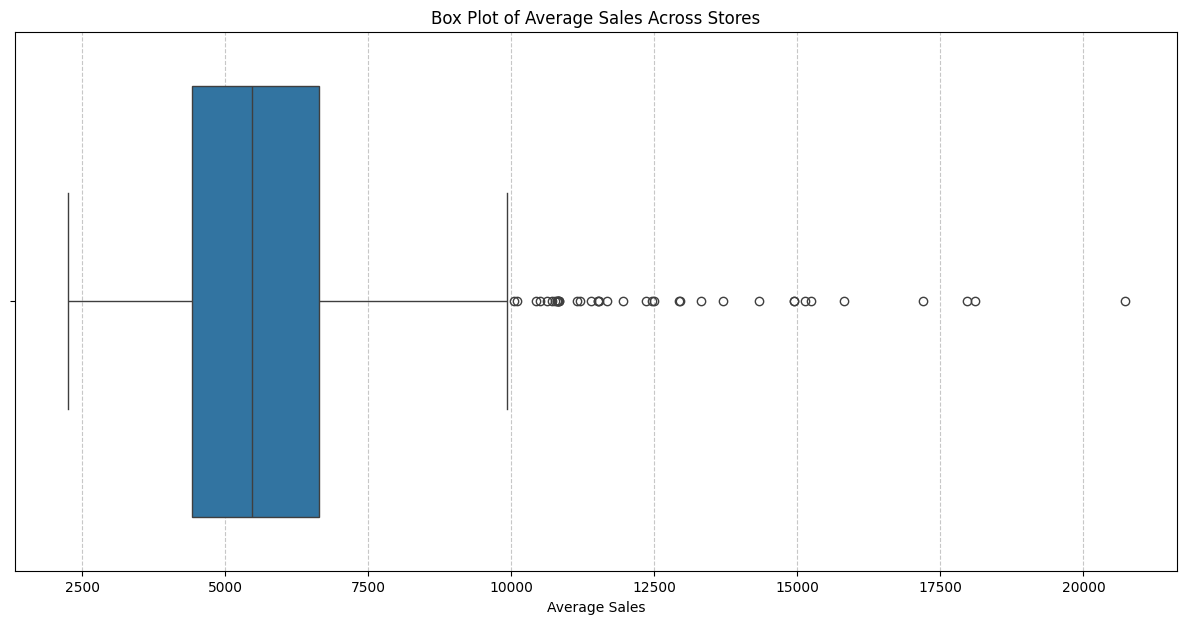

In [71]:
plt.figure(figsize=(15, 7))
sns.boxplot(x=store_sales['Sales'])
plt.title('Box Plot of Average Sales Across Stores')
plt.xlabel('Average Sales')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

how many store types , categories are there and how many stores belong to each, in store.csv

### 6.10 Store EDA - Store Types and Assortments

In [72]:
store['StoreType'].value_counts()

,count
StoreType,
a,602
d,348
c,148
b,17


In [73]:
store['Assortment'].value_counts()

,count
Assortment,
a,593
c,513
b,9


In [74]:
train[train['Store']==622].value_counts()

Store  DayOfWeek  Date        Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday
622    7          2015-07-26  0      0          0     0      0             0                1
       1          2013-01-07  5887   555        1     1      0             0                1
                  2013-01-14  3574   399        1     0      0             0                1
                  2013-01-21  5266   476        1     1      0             0                1
                  2013-01-28  3461   391        1     0      0             0                1
                                                                                           ..
                  2013-05-13  5746   555        1     1      0             0                1
                  2013-05-06  4103   442        1     0      0             0                1
                  2013-04-29  4629   468        1     1      0             0                1
                  2013-04-22  4873   505        1     1      0             0                1
                  2013-04-15  3244   390        1     0      0             0                1
Name: count, Length: 942, dtype: int64

In [75]:
store_622 = train[train['Store'] == 622]
pd.crosstab(store_622['DayOfWeek'], store_622['Open'])

Open,0,1
DayOfWeek,,
1,6,128
2,1,134
3,3,132
4,8,127
5,6,129
6,0,134
7,134,0


### Train Dataset — Exploratory Data Analysis Conclusion

The training dataset contains **1,017,209 daily observations** covering **1 January 2013 to 31 July 2015** across **1,115 stores**. The analysis shows that sales are influenced by several operational, customer, calendar, promotional, and store-level factors.

**1. Store operations:**
Store opening status is strongly related to sales. When a store is closed (`Open = 0`), sales and customers are generally zero. However, 54 observations were found where stores were marked as open but recorded zero sales. Most of these also had zero customers, so they were retained rather than automatically treated as errors.

**2. Promotions:**
Days with promotions had substantially higher average sales than non-promotion days. Average sales were approximately **7,991** during promotional days compared with **4,406** on non-promotional days. This shows a strong association between promotions and sales, although the analysis does not establish that promotions alone caused the difference.

**3. Day of week:**
Sales vary considerably across the week. Raw sales for Sunday appeared extremely low because stores were almost always closed. After restricting the analysis to open stores, Sunday had the highest average sales (**~8,225**), accompanied by substantially higher customer traffic. However, sales per customer were lowest on Sunday, indicating that its high sales were associated more with customer volume than higher spending per customer.

**4. State holidays:**
State holidays were strongly associated with store closures, with only around **2–3% of observations open** on the holiday categories. Consequently, raw sales were much lower on holidays. Among stores that remained open, average sales were higher than on normal days, but these results are based on relatively few observations and should therefore be interpreted cautiously.

**5. School holidays:**
School holidays were associated with somewhat higher sales. The difference remained after restricting the analysis to open stores, although it became considerably smaller. School holidays also occurred predominantly on weekdays, where sales patterns differ from weekends. Therefore, the observed relationship should not be interpreted as a direct causal effect.

**6. Time and seasonality:**
Sales fluctuate over time rather than following a simple continuous upward trend. A recurring seasonal pattern was observed, particularly around the end of the year. **December consistently showed the highest average sales**, including when the analysis was restricted to open stores. This indicates that month/season is likely to be an important consideration for future sales forecasting.

**7. Customer traffic:**
Customers and Sales showed a strong positive correlation of approximately **0.82** among open-store observations. This means observations with more customers generally had higher sales. Customer traffic therefore appears to be an important predictor of sales, although correlation does not establish causation. A practical modeling limitation is that `Customers` is not available in the test dataset.

**8. Sales distribution and outliers:**
Sales had a mean of approximately **5,774** and a median of **5,744**, with values ranging from **0 to 41,551**. Using the IQR method identified approximately **26,694 observations (2.62%)** as statistical outliers. Further inspection showed that high-sales observations generally had substantially higher customer counts, suggesting that many of these extreme values may represent genuine high-demand situations rather than data errors. Therefore, they should not be removed automatically.

**9. Store-level differences:**
Average sales varied substantially between stores. Across the 1,115 stores, average daily sales ranged from approximately **2,245 to 20,719**, demonstrating considerable store-to-store variation. This suggests that store-specific characteristics may be important for explaining and predicting sales and motivates further investigation using the `store.csv` dataset.

### Overall Finding

Overall, the Train EDA shows that **sales are not uniform across stores or time**. Store operating status, promotions, day of week, holidays, seasonality, customer traffic, and store-specific differences are all associated with variations in sales. These findings provide a strong foundation for the next stages of the project: understanding the Test and Store datasets, connecting the datasets through `Store`, creating useful features, and eventually developing a sales-prediction model.


### 6.14 Test EDA

**Test EDA**

### 6.15 Store EDA - Initial Look

In [76]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [77]:
test.describe()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000


In [78]:
test.isnull().sum()

,0
Id,0
Store,0
DayOfWeek,0
Date,0
Open,11
Promo,0
StateHoliday,0
SchoolHoliday,0


In [79]:
test[test['Open'].isna()]

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
479,480,622,4,2015-09-17,NaN,1,0,0
1335,1336,622,3,2015-09-16,NaN,1,0,0
2191,2192,622,2,2015-09-15,NaN,1,0,0
3047,3048,622,1,2015-09-14,NaN,1,0,0
4759,4760,622,6,2015-09-12,NaN,0,0,0
5615,5616,622,5,2015-09-11,NaN,0,0,0
6471,6472,622,4,2015-09-10,NaN,0,0,0
7327,7328,622,3,2015-09-09,NaN,0,0,0
8183,8184,622,2,2015-09-08,NaN,0,0,0
9039,9040,622,1,2015-09-07,NaN,0,0,0


In [80]:
pd.crosstab(test['DayOfWeek'], test['Open'], normalize='index')

Open,0.0,1.0
DayOfWeek,,
1,0.000668,0.999332
2,0.000668,0.999332
3,0.000668,0.999332
4,0.000501,0.999499
5,0.000195,0.999805
6,0.027546,0.972454
7,0.968458,0.031542


In [81]:
pd.crosstab(test['StateHoliday'], test['Open'], normalize='index')

Open,0.0,1.0
StateHoliday,,
0,0.142553,0.857447
a,0.855556,0.144444


In [82]:
pd.crosstab(test['Promo'], test['Open'], normalize='index')

Open,0.0,1.0
Promo,,
0,0.240641,0.759359
1,0.000738,0.999262


In [83]:
test['Open'] = test['Open'].fillna(1)

In [84]:
test['StateHoliday'].value_counts()

,count
StateHoliday,
0,40908
a,180


In [85]:
test['StateHoliday'].unique()

array(['0', 'a'], dtype=object)

In [86]:
test['SchoolHoliday'].value_counts()

,count
SchoolHoliday,
0,22866
1,18222


In [87]:
test['SchoolHoliday'].isnull().sum()


np.int64(0)

In [88]:
test['SchoolHoliday'].unique()

array([0, 1])

In [89]:
test['DayOfWeek'].value_counts()

,count
DayOfWeek,
4,5992
3,5992
2,5992
1,5992
7,5992
6,5992
5,5136


In [90]:
test['Promo'].value_counts()

,count
Promo,
0,24824
1,16264


Store Exploratory Data Analysis

## 7. Feature Engineering

In [91]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [92]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [93]:
store.isnull().sum()


,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [94]:
store['StoreType'].value_counts()

,count
StoreType,
a,602
d,348
c,148
b,17


In [95]:
store['Assortment'].value_counts()

,count
Assortment,
a,593
c,513
b,9


In [96]:
pd.crosstab(store['StoreType'],store['Assortment'])

Assortment,a,b,c
StoreType,,,
a,381,0,221
b,7,9,1
c,77,0,71
d,128,0,220


In [97]:
store['CompetitionDistance'].describe()

,CompetitionDistance
count,1112.000000
mean,5404.901079
std,7663.174720
min,20.000000
25%,717.500000
50%,2325.000000
75%,6882.500000
max,75860.000000


find store where competition is missing


In [98]:
store['CompetitionDistance'].isna().sum()

np.int64(3)

In [99]:
store[store['CompetitionDistance'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Competieion since month

### 6.11 Store EDA - Competition Distance and Open Date

In [100]:
store['CompetitionOpenSinceMonth'].value_counts()

,count
CompetitionOpenSinceMonth,
9.0,125
4.0,94
11.0,92
3.0,70
7.0,67
12.0,64
10.0,61
6.0,50
5.0,44


In [101]:
store['CompetitionOpenSinceMonth'].isnull().sum()

np.int64(354)

In [102]:
store[store['CompetitionOpenSinceMonth'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [103]:
# Calculate the percentage of stores with missing 'CompetitionOpenSinceMonth'
missing_competition_month = store['CompetitionOpenSinceMonth'].isnull().sum()
total_stores = len(store)
percentage_missing_competition_month = (missing_competition_month / total_stores) * 100

print(f"Number of stores with missing 'CompetitionOpenSinceMonth': {missing_competition_month}")
print(f"Total number of stores: {total_stores}")
print(f"Percentage of stores with missing 'CompetitionOpenSinceMonth': {percentage_missing_competition_month:.2f}%")

Number of stores with missing 'CompetitionOpenSinceMonth': 354
Total number of stores: 1115
Percentage of stores with missing 'CompetitionOpenSinceMonth': 31.75%


In [104]:
# Calculate the percentage of stores with ANY missing data in the store DataFrame
stores_with_any_missing_data = store.isnull().any(axis=1).sum()
percentage_any_missing_data = (stores_with_any_missing_data / total_stores) * 100

print(f"\nNumber of stores with any missing data: {stores_with_any_missing_data}")
print(f"Percentage of stores with any missing data: {percentage_any_missing_data:.2f}%")


Number of stores with any missing data: 750
Percentage of stores with any missing data: 67.26%


In [105]:
# 1. Percentage of stores missing 'CompetitionOpenSinceMonth'
missing_competition_month = store['CompetitionOpenSinceMonth'].isnull().sum()
total_stores = len(store)
percentage_missing_competition_month = (missing_competition_month / total_stores) * 100

print(f"Percentage of stores missing 'CompetitionOpenSinceMonth': {percentage_missing_competition_month:.2f}%")

Percentage of stores missing 'CompetitionOpenSinceMonth': 31.75%


In [106]:
# 2. Percentage of stores with ANY missing data
stores_with_any_missing_data = store.isnull().any(axis=1).sum()
percentage_any_missing_data = (stores_with_any_missing_data / total_stores) * 100

print(f"Percentage of stores with ANY missing data: {percentage_any_missing_data:.2f}%")

Percentage of stores with ANY missing data: 67.26%


In [107]:
missing_competition_year=store['CompetitionOpenSinceYear'].isnull().sum()
total_stores=len(store)
percentage_missing_competition_Year=(missing_competition_year/total_stores)*100
print(f"Percentage of stores missing 'CompetitionOpenSinceYear': {percentage_missing_competition_Year:.2f}%")

Percentage of stores missing 'CompetitionOpenSinceYear': 31.75%


different store types have how many missing values

In [108]:
store['StoreType'].value_counts()

,count
StoreType,
a,602
d,348
c,148
b,17


In [109]:
store['StoreType'].isnull()

,StoreType
0,False
1,False
2,False
3,False
4,False
...,...
1110,False
1111,False
1112,False
1113,False


In [110]:
missing_competition_data_by_storetype = store.groupby('StoreType')[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']].apply(lambda x: x.isnull().sum())

total_stores_by_type = store.groupby('StoreType').size().rename('TotalStores')

# Combine missing counts with total stores to calculate percentages
missing_data_summary = pd.concat([missing_competition_data_by_storetype, total_stores_by_type], axis=1)

missing_data_summary['PercentageMissingMonth'] = (missing_data_summary['CompetitionOpenSinceMonth'] / missing_data_summary['TotalStores']) * 100
missing_data_summary['PercentageMissingYear'] = (missing_data_summary['CompetitionOpenSinceYear'] / missing_data_summary['TotalStores']) * 100

display(missing_data_summary)

,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,TotalStores,PercentageMissingMonth,PercentageMissingYear
StoreType,,,,,
a,176,176,602,29.235880,29.235880
b,8,8,17,47.058824,47.058824
c,41,41,148,27.702703,27.702703
d,129,129,348,37.068966,37.068966


In [111]:
# Check whether Month and Year are missing together

month_missing = store['CompetitionOpenSinceMonth'].isna()
year_missing = store['CompetitionOpenSinceYear'].isna()

print("Month missing, Year present:", (month_missing & ~year_missing).sum())
print("Month present, Year missing:", (~month_missing & year_missing).sum())
print("Both missing:", (month_missing & year_missing).sum())
print("Both present:", (~month_missing & ~year_missing).sum())

Month missing, Year present: 0
Month present, Year missing: 0
Both missing: 354
Both present: 761


In [112]:
store[store['CompetitionOpenSinceMonth'].isna()]['Promo2'].value_counts()

,count
Promo2,
1,206
0,148


In [113]:
store[store['CompetitionOpenSinceYear'].isna()]['Promo2'].value_counts()

,count
Promo2,
1,206
0,148


In [114]:
pd.crosstab(
    store['Promo2'],
    store['CompetitionOpenSinceMonth'].isna()
)

CompetitionOpenSinceMonth,False,True
Promo2,,
0,396,148
1,365,206


In [115]:
pd.crosstab(
    store['StoreType'],
    store['CompetitionOpenSinceMonth'].isna()
)

CompetitionOpenSinceMonth,False,True
StoreType,,
a,426,176
b,9,8
c,107,41
d,219,129


In [116]:
pd.crosstab(
    store['CompetitionOpenSinceYear'].isna(),
    store['CompetitionOpenSinceMonth'].isna()
)

CompetitionOpenSinceMonth,False,True
CompetitionOpenSinceYear,,
False,761,0
True,0,354


In [117]:
pd.crosstab(
    store['StoreType'],
    store['CompetitionOpenSinceMonth'].isna(),
    normalize='index'
) * 100

CompetitionOpenSinceMonth,False,True
StoreType,,
a,70.764120,29.235880
b,52.941176,47.058824
c,72.297297,27.702703
d,62.931034,37.068966


The missing competition dates appear to represent a distinct subset of stores, but we don't yet have evidence that their missing values can be reliably reconstructed from the information we've examined.

Promo2

In [118]:
store[['Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']].isnull().sum()

,0
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [119]:
pd.crosstab(
    store['Promo2'],
    store['Promo2SinceWeek'].isna()
)


Promo2SinceWeek,False,True
Promo2,,
0,0,544
1,571,0


In [120]:
pd.crosstab(
    store['Promo2'],
    store['Promo2SinceYear'].isna()
)

Promo2SinceYear,False,True
Promo2,,
0,0,544
1,571,0


In [121]:
pd.crosstab(
    store['Promo2'],
    store['PromoInterval'].isna()
)

PromoInterval,False,True
Promo2,,
0,0,544
1,571,0


Promo2SinceWeek, Promo2SinceYear, and PromoInterval have structural missingness: they are not applicable when a store does not participate in Promo2.

In [122]:
store.loc[store['Promo2'] == 1,
          ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']].describe(include='all')

,Promo2SinceWeek,Promo2SinceYear,PromoInterval
count,571.000000,571.000000,571
unique,NaN,NaN,3
top,NaN,NaN,"Jan,Apr,Jul,Oct"
freq,NaN,NaN,335
mean,23.595447,2011.763573,NaN
std,14.141984,1.674935,NaN
min,1.000000,2009.000000,NaN
25%,13.000000,2011.000000,NaN
50%,22.000000,2012.000000,NaN
75%,37.000000,2013.000000,NaN


In [123]:
store.loc[store['Promo2'] == 1, 'PromoInterval'].value_counts()

,count
PromoInterval,
"Jan,Apr,Jul,Oct",335
"Feb,May,Aug,Nov",130
"Mar,Jun,Sept,Dec",106


In [124]:
store.loc[store['Promo2'] == 1, 'Promo2SinceWeek'].value_counts().sort_index()

,count
Promo2SinceWeek,
1.0,35
5.0,39
6.0,1
9.0,14
10.0,42
13.0,34
14.0,81
18.0,29
22.0,33


Promo2SinceWeek → valid range
Promo2SinceYear → valid-looking years
PromoInterval → exactly 3 valid categories
Structural missingness → understood

In [125]:
store.loc[store['Promo2'] == 1, 'Promo2SinceYear'].value_counts().sort_index()

,count
Promo2SinceYear,
2009.0,73
2010.0,64
2011.0,128
2012.0,81
2013.0,120
2014.0,95
2015.0,10


### 6.13 Train Dataset — Exploratory Data Analysis Conclusion

Years range from 2009 to 2015 — all reasonable.
No unexpected or invalid year values.
There are only 10 stores starting Promo2 in 2015, while 2011 and 2013 have more.
Combined with our previous checks:
Promo2 = 0 → Promo2SinceWeek/Year/Interval are structurally missing.
Promo2 = 1 → those fields are complete and contain sensible values.

In [126]:
store['Store'].duplicated().sum()


np.int64(0)

**Merging**

In [127]:
train_merged = train.merge(store, on='Store', how='left')

In [128]:
print(train_merged.shape)
print(train_merged.shape[0] == train.shape[0])
print(train_merged.isnull().sum())

(1017209, 18)
True
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


comparison

Average Sales by StoreType, where Open == 1.

In [129]:
train_merged[train_merged['Open']==1].groupby('StoreType')['Sales'].mean()

,Sales
StoreType,
a,6925.167661
b,10231.407505
c,6932.512755
d,6822.141881


In [130]:
train_merged.groupby('StoreType')['Store'].nunique()

,Store
StoreType,
a,602
b,17
c,148
d,348


In [131]:
store_sales = (
    train_merged[train_merged['Open'] == 1]
    .groupby(['StoreType', 'Store'])['Sales']
    .mean()
)

store_sales.loc['b'].sort_values(ascending=False)

,Sales
Store,
262,20718.515924
562,17969.556263
733,14933.288747
335,13313.939490
259,11643.638412
682,11207.408705
423,10828.403397
769,10825.902335
1097,9744.599788


StoreType b is associated with a higher average Sales in this dataset, but the small number of Type-b stores and their substantial variation mean we should interpret this association cautiously.

assortment

In [132]:
train_merged[train_merged['Open']==1].groupby('Assortment')['Sales'].mean()

,Sales
Assortment,
a,6621.017039
b,8639.346322
c,7300.526339


In [133]:
train_merged.groupby('Assortment')['Store'].nunique()

,Store
Assortment,
a,593
b,9
c,513


In [134]:
store_sales = (
    train_merged[train_merged['Open'] == 1]
    .groupby(['Assortment', 'Store'])['Sales']
    .mean()
)

store_sales.loc['b'].sort_values(ascending=False)

,Sales
Store,
733,14933.288747
259,11643.638412
769,10825.902335
1097,9744.599788
676,7687.464052
948,6936.760776
353,5645.298604
512,5510.978523
274,4070.828326


This means some of the apparent Sales difference associated with Assortment may actually be related to the characteristics of those particular StoreTypes/stores.

competition distance

In [135]:
distance_analysis = train_merged[train_merged['Open'] == 1].copy()

distance_analysis['DistanceGroup'] = pd.qcut(
    distance_analysis['CompetitionDistance'],
    q=5
)

distance_analysis.groupby('DistanceGroup', observed=True)['Sales'].mean()

,Sales
DistanceGroup,
"(19.999, 510.0]",7596.008472
"(510.0, 1590.0]",6836.670196
"(1590.0, 3460.0]",6729.701250
"(3460.0, 8780.0]",6793.139082
"(8780.0, 75860.0]",6836.504177


In [136]:
train_merged[train_merged['CompetitionDistance'].isna()][
    ['Store', 'StoreType', 'Assortment', 'Sales']
].drop_duplicates('Store')

,Store,StoreType,Assortment,Sales
290,291,d,a,10052
621,622,a,c,6306
878,879,d,a,6000


In [137]:
train_merged[
    train_merged['CompetitionDistance'].isna() &
    (train_merged['Open'] == 1)
].groupby(['Store', 'StoreType', 'Assortment'])['Sales'].mean()


,,,Sales
Store,StoreType,Assortment,
291,d,a,8023.039744
622,a,c,4317.961735
879,d,a,3762.983923


vCompetitionDistance is strongly right-skewed. The closest-distance group had higher average Sales, while the remaining distance groups showed relatively similar Sales. This suggests an association rather than a clear monotonic relationship. Only 3 stores have missing CompetitionDistance, so the missingness is limited and does not appear to follow a simple StoreType/Assortment pattern.

In [138]:
train_merged['CompetitionOpenDate'] = pd.to_datetime(
    train_merged['CompetitionOpenSinceYear'].astype('Int64').astype(str) + '-' +
    train_merged['CompetitionOpenSinceMonth'].astype('Int64').astype(str) + '-01',
    errors='coerce'
)

In [139]:
train_merged['CompetitionAgeMonths'] = (
    (train_merged['Date'].dt.year - train_merged['CompetitionOpenDate'].dt.year) * 12
    + (train_merged['Date'].dt.month - train_merged['CompetitionOpenDate'].dt.month)
)

In [140]:
train_merged[
    ['Date', 'CompetitionOpenDate', 'CompetitionAgeMonths']
].head(10)

,Date,CompetitionOpenDate,CompetitionAgeMonths
0,2015-07-31,2008-09-01,82.0
1,2015-07-31,2007-11-01,92.0
2,2015-07-31,2006-12-01,103.0
3,2015-07-31,2009-09-01,70.0
4,2015-07-31,2015-04-01,3.0
5,2015-07-31,2013-12-01,19.0
6,2015-07-31,2013-04-01,27.0
7,2015-07-31,2014-10-01,9.0
8,2015-07-31,2000-08-01,179.0
9,2015-07-31,2009-09-01,70.0


In [141]:
train_merged['CompetitionAgeMonths'].isna().sum()

np.int64(323348)

In [142]:
train_merged['CompetitionAgeMonths'].describe()

,CompetitionAgeMonths
count,693861.000000
mean,60.325453
std,72.333492
min,-31.000000
25%,14.000000
50%,51.000000
75%,94.000000
max,1386.000000


In [143]:
(train_merged['CompetitionAgeMonths'] < 0).sum()

np.int64(84666)

In [144]:
train_merged.loc[
    train_merged['CompetitionAgeMonths'] < 0,
    ['Store', 'Date', 'CompetitionOpenDate', 'CompetitionAgeMonths']
].head(10)

,Store,Date,CompetitionOpenDate,CompetitionAgeMonths
687,688,2015-07-31,2015-08-01,-1.0
1019,1020,2015-07-31,2015-08-01,-1.0
1071,1072,2015-07-31,2015-08-01,-1.0
1802,688,2015-07-30,2015-08-01,-1.0
2134,1020,2015-07-30,2015-08-01,-1.0
2186,1072,2015-07-30,2015-08-01,-1.0
2917,688,2015-07-29,2015-08-01,-1.0
3249,1020,2015-07-29,2015-08-01,-1.0
3301,1072,2015-07-29,2015-08-01,-1.0
4032,688,2015-07-28,2015-08-01,-1.0


In [145]:
train_merged.loc[
    train_merged['CompetitionAgeMonths'] == train_merged['CompetitionAgeMonths'].max(),
    ['Store', 'Date', 'CompetitionOpenDate', 'CompetitionAgeMonths']
].head()

,Store,Date,CompetitionOpenDate,CompetitionAgeMonths
814,815,2015-07-31,1900-01-01,1386.0
1929,815,2015-07-30,1900-01-01,1386.0
3044,815,2015-07-29,1900-01-01,1386.0
4159,815,2015-07-28,1900-01-01,1386.0
5274,815,2015-07-27,1900-01-01,1386.0


In [146]:
train_merged.loc[
    train_merged['CompetitionAgeMonths'] > 600,
    ['Store', 'CompetitionOpenDate', 'CompetitionAgeMonths']
].drop_duplicates().sort_values('CompetitionAgeMonths').head(20)

,Store,CompetitionOpenDate,CompetitionAgeMonths
982790,146,1961-10-01,615.0
951570,146,1961-10-01,616.0
917005,146,1961-10-01,617.0
883555,146,1961-10-01,618.0
848990,146,1961-10-01,619.0
815540,146,1961-10-01,620.0
780975,146,1961-10-01,621.0
746410,146,1961-10-01,622.0
712960,146,1961-10-01,623.0
678395,146,1961-10-01,624.0


In [147]:
train_merged.loc[
    train_merged['CompetitionOpenDate'] == '1900-01-01',
    'Store'
].nunique()

1

In [148]:
train_merged.loc[
    train_merged['CompetitionOpenDate'].dt.year < 1990,
    ['Store', 'CompetitionOpenDate']
].drop_duplicates().sort_values('CompetitionOpenDate')

,Store,CompetitionOpenDate
814,815,1900-01-01
145,146,1961-10-01


In [149]:
train_merged[
    train_merged['Store'] == 815
][[
    'Store',
    'StoreType',
    'Assortment',
    'CompetitionDistance',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'CompetitionOpenDate',
    'CompetitionAgeMonths'
]].drop_duplicates()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionOpenDate,CompetitionAgeMonths
814,815,a,a,590.0,1.0,1900.0,1900-01-01,1386.0
35379,815,a,a,590.0,1.0,1900.0,1900-01-01,1385.0
68829,815,a,a,590.0,1.0,1900.0,1900-01-01,1384.0
103394,815,a,a,590.0,1.0,1900.0,1900-01-01,1383.0
136844,815,a,a,590.0,1.0,1900.0,1900-01-01,1382.0
171409,815,a,a,590.0,1.0,1900.0,1900-01-01,1381.0
202629,815,a,a,590.0,1.0,1900.0,1900-01-01,1380.0
409234,815,a,a,590.0,1.0,1900.0,1900-01-01,1373.0
442684,815,a,a,590.0,1.0,1900.0,1900-01-01,1372.0
477249,815,a,a,590.0,1.0,1900.0,1900-01-01,1371.0


In [150]:
store[store['CompetitionOpenSinceYear'] == 1900][
    ['Store', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
]

,Store,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
814,815,1.0,1900.0


In [151]:
train_merged.loc[
    train_merged['CompetitionOpenSinceYear'] == 1900,
    ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
] = np.nan

In [152]:
train_merged['CompetitionOpenDate'] = pd.to_datetime(
    train_merged['CompetitionOpenSinceYear'].astype('Int64').astype(str) + '-' +
    train_merged['CompetitionOpenSinceMonth'].astype('Int64').astype(str) + '-01',
    errors='coerce'
)

In [153]:
train_merged['CompetitionAgeMonths'] = (
    (train_merged['Date'].dt.year - train_merged['CompetitionOpenDate'].dt.year) * 12
    + (train_merged['Date'].dt.month - train_merged['CompetitionOpenDate'].dt.month)
)

In [154]:
train_merged['CompetitionAgeMonths'].describe()

,CompetitionAgeMonths
count,693103.000000
mean,58.893498
std,57.972108
min,-31.000000
25%,14.000000
50%,51.000000
75%,94.000000
max,645.000000


In [155]:
train_merged['CompetitionAgeMonths'].isna().sum()

np.int64(324106)

In [156]:
competition_analysis = train_merged[
    (train_merged['Open'] == 1) &
    (train_merged['CompetitionAgeMonths'].notna())
].copy()

competition_analysis['CompetitionStatus'] = np.where(
    competition_analysis['CompetitionAgeMonths'] < 0,
    'Not yet open',
    'Already open'
)

competition_analysis.groupby('CompetitionStatus')['Sales'].agg(
    ['count', 'mean']
)

,count,mean
CompetitionStatus,,
Already open,505043,6930.238332
Not yet open,70108,7215.283591


In [157]:
age_analysis = competition_analysis[
    competition_analysis['CompetitionAgeMonths'] >= 0
].copy()

age_analysis['CompetitionAgeGroup'] = pd.qcut(
    age_analysis['CompetitionAgeMonths'],
    q=5
)

age_analysis.groupby(
    'CompetitionAgeGroup',
    observed=True
)['Sales'].agg(['count', 'mean'])

,count,mean
CompetitionAgeGroup,,
"(-0.001, 20.0]",103676,7124.395415
"(20.0, 46.0]",100340,6914.916434
"(46.0, 75.0]",99457,6927.839478
"(75.0, 108.0]",101920,6768.820153
"(108.0, 645.0]",99650,6911.154471


In [158]:
store[store['Store'] == 146]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
145,146,d,c,8050.0,10.0,1961.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct"


In [159]:
train_merged[train_merged['Store'] == 146][
    ['Date', 'Sales', 'CompetitionAgeMonths']
].head(10)

,Date,Sales,CompetitionAgeMonths
145,2015-07-31,10130,645.0
1260,2015-07-30,8798,645.0
2375,2015-07-29,8597,645.0
3490,2015-07-28,8484,645.0
4605,2015-07-27,11645,645.0
5720,2015-07-26,0,645.0
6835,2015-07-25,6002,645.0
7950,2015-07-24,6448,645.0
9065,2015-07-23,5933,645.0
10180,2015-07-22,6417,645.0


In [160]:
train_merged[train_merged['Store'] == 146]['Sales'].mean()

np.float64(6460.928874734607)

Competition age shows some variation in average Sales, with the youngest competition group (0–20 months) having the highest average Sales. However, the pattern is not consistently increasing or decreasing across age groups, so there is no clear linear relationship between competition age and Sales.

promo2, sales

### 6.12 Store EDA - Promo2

In [161]:
promo2_sales = train_merged[train_merged['Open'] == 1].groupby('Promo2')['Sales'].agg(
    ['count', 'mean']
)

promo2_sales

,count,mean
Promo2,,
0,423307,7350.557935
1,421085,6558.386062


In [162]:
pd.crosstab(
    store['StoreType'],
    store['Promo2']
)

Promo2,0,1
StoreType,,
a,313,289
b,12,5
c,73,75
d,146,202


In [163]:
train_merged[train_merged['Open'] == 1].groupby(
    ['StoreType', 'Promo2']
)['Sales'].agg(['count', 'mean'])

count          mean
StoreType Promo2                      
a         0       244059   7193.916672
          1       213018   6617.256523
b         0        11071  11140.475115
          1         4492   7990.916073
c         0        56763   7664.076599
          1        56215   6193.817415
d         0       111414   7157.362082
          1       147360   6568.693024

In [164]:
store_promo_sales = train_merged[train_merged['Open'] == 1].groupby(
    ['Store', 'Promo2']
)['Sales'].mean().reset_index()

store_promo_sales.groupby('Promo2')['Sales'].agg(['count', 'mean', 'median'])

,count,mean,median
Promo2,,,
0,544,7337.391682,6936.306575
1,571,6550.089921,6267.489060


Promo2 participation is associated with lower average Sales among open stores. This pattern remains within each StoreType, suggesting that the overall difference is not explained solely by StoreType composition. However, this is an observational association and does not establish that Promo2 participation causes lower Sales.

In [165]:
train_merged[
    (train_merged['Open'] == 1) &
    (train_merged['Promo2'] == 1)
].groupby('PromoInterval')['Sales'].agg(['count', 'mean'])

,count,mean
PromoInterval,,
"Feb,May,Aug,Nov",98005,6426.907994
"Jan,Apr,Jul,Oct",242411,6725.978932
"Mar,Jun,Sept,Dec",80669,6214.501209


In [166]:
train_merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenDate,CompetitionAgeMonths
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2008-09-01,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2007-11-01,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2006-12-01,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2009-09-01,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015-04-01,3.0


i think we can remove customers , customer id, promo2 since a week , prommo2 since a year,

Feature Engineering

## 8. Train-Validation Split

In [167]:
train_merged['Year'] = train_merged['Date'].dt.year
train_merged['Month'] = train_merged['Date'].dt.month
train_merged['Day'] = train_merged['Date'].dt.day
train_merged['WeekOfYear'] = train_merged['Date'].dt.isocalendar().week

In [168]:
train_merged[['Date', 'Year', 'Month', 'Day', 'WeekOfYear']].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [169]:
train_merged[['Year', 'Month', 'Day', 'WeekOfYear']].describe()

,Year,Month,Day,WeekOfYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1017209.0
mean,2.013832e+03,5.846762e+00,1.570279e+01,23.615515
std,7.773960e-01,3.326097e+00,8.787638e+00,14.433381
min,2.013000e+03,1.000000e+00,1.000000e+00,1.0
25%,2.013000e+03,3.000000e+00,8.000000e+00,11.0
50%,2.014000e+03,6.000000e+00,1.600000e+01,22.0
75%,2.014000e+03,8.000000e+00,2.300000e+01,35.0
max,2.015000e+03,1.200000e+01,3.100000e+01,52.0


In [170]:
print(train_merged['Year'].unique())
print(train_merged['Month'].unique())
print(train_merged['Day'].min(), train_merged['Day'].max())
print(train_merged['WeekOfYear'].min(), train_merged['WeekOfYear'].max())

[2015 2014 2013]
[ 7  6  5  4  3  2  1 12 11 10  9  8]
1 31
1 52


promo2 active

In [171]:
train_merged['Promo2Active'] = (
    (train_merged['Promo2'] == 1) &
    (
        ((train_merged['PromoInterval'] == 'Jan,Apr,Jul,Oct') &
         (train_merged['Month'].isin([1, 4, 7, 10]))) |

        ((train_merged['PromoInterval'] == 'Feb,May,Aug,Nov') &
         (train_merged['Month'].isin([2, 5, 8, 11]))) |

        ((train_merged['PromoInterval'] == 'Mar,Jun,Sept,Dec') &
         (train_merged['Month'].isin([3, 6, 9, 12])))
    )
).astype(int)

In [172]:
train_merged['Promo2Active'].value_counts()

,count
Promo2Active,
0,842417
1,174792


In [173]:
train_merged[
    ['Date', 'Month', 'Promo2', 'PromoInterval', 'Promo2Active']
].head(20)

,Date,Month,Promo2,PromoInterval,Promo2Active
0,2015-07-31,7,0,NaN,0
1,2015-07-31,7,1,"Jan,Apr,Jul,Oct",1
2,2015-07-31,7,1,"Jan,Apr,Jul,Oct",1
3,2015-07-31,7,0,NaN,0
4,2015-07-31,7,0,NaN,0
5,2015-07-31,7,0,NaN,0
6,2015-07-31,7,0,NaN,0
7,2015-07-31,7,0,NaN,0
8,2015-07-31,7,0,NaN,0
9,2015-07-31,7,0,NaN,0


In [174]:
promo2_2015 = train_merged[
    (train_merged['Promo2'] == 1) &
    (train_merged['Promo2SinceYear'] == 2015)
]

promo2_2015[['Date', 'Promo2SinceWeek']].sort_values('Date').head(20)

,Date,Promo2SinceWeek
1017040,2013-01-01,14.0
1016122,2013-01-01,6.0
1016359,2013-01-01,14.0
1016425,2013-01-01,14.0
1016522,2013-01-01,23.0
1016970,2013-01-01,18.0
1016843,2013-01-01,14.0
1016969,2013-01-01,18.0
1016723,2013-01-01,23.0
1016966,2013-01-01,23.0


In [175]:
train_merged['Promo2Active'].value_counts()

,count
Promo2Active,
0,842417
1,174792


In [176]:
train_merged[
    ['Date', 'Month', 'Promo2', 'PromoInterval', 'Promo2Active']
].head(20)

,Date,Month,Promo2,PromoInterval,Promo2Active
0,2015-07-31,7,0,NaN,0
1,2015-07-31,7,1,"Jan,Apr,Jul,Oct",1
2,2015-07-31,7,1,"Jan,Apr,Jul,Oct",1
3,2015-07-31,7,0,NaN,0
4,2015-07-31,7,0,NaN,0
5,2015-07-31,7,0,NaN,0
6,2015-07-31,7,0,NaN,0
7,2015-07-31,7,0,NaN,0
8,2015-07-31,7,0,NaN,0
9,2015-07-31,7,0,NaN,0


dropping

In [177]:
train_merged = train_merged.drop(columns=['Promo2SinceWeek','Promo2SinceYear'])

In [178]:
# train_merged = train_merged.drop(columns=['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'CompetitionOpenDate']) # Already dropped

In [179]:
train_merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,PromoInterval,CompetitionOpenDate,CompetitionAgeMonths,Year,Month,Day,WeekOfYear,Promo2Active
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,2008-09-01,82.0,2015,7,31,31,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,"Jan,Apr,Jul,Oct",2007-11-01,92.0,2015,7,31,31,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,"Jan,Apr,Jul,Oct",2006-12-01,103.0,2015,7,31,31,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,2009-09-01,70.0,2015,7,31,31,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,2015-04-01,3.0,2015,7,31,31,0


In [180]:
train_merged['Date'] = train['Date']
split_date = pd.to_datetime('2015-05-31')
train_df = train_merged[train_merged['Date'] <= split_date]
validation_df = train_merged[train_merged['Date'] > split_date]


## 9. Data Preprocessing

In [181]:
split_date = pd.to_datetime('2015-05-31')
train_df = train_merged[train_merged['Date'] <= split_date]
validation_df = train_merged[train_merged['Date'] > split_date]


In [182]:
print(f'Shape of training data: {train_df.shape}')
print(f'Shape of validation data: {validation_df.shape}')


Shape of training data: (949194, 23)
Shape of validation data: (68015, 23)


In [183]:
train.loc[train.index.isin(train_df.index), 'Date'].min(), \
train.loc[train.index.isin(train_df.index), 'Date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-05-31 00:00:00'))

In [184]:
train.loc[train.index.isin(validation_df.index), 'Date'].min(), \
train.loc[train.index.isin(validation_df.index), 'Date'].max()

(Timestamp('2015-06-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [185]:
train_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [186]:
validation_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [187]:
train_df.groupby('Promo2')['PromoInterval'].apply(lambda x: x.isna().sum())

,PromoInterval
Promo2,
0,474847
1,0


In [188]:
train_df.loc[
    train_df['CompetitionAgeMonths'].isna(),
    'Store'
].nunique()

355

In [189]:
age_missing_stores = set(
    train_df.loc[train_df['CompetitionAgeMonths'].isna(), 'Store']
)

distance_missing_stores = set(
    train_df.loc[train_df['CompetitionDistance'].isna(), 'Store']
)

len(age_missing_stores & distance_missing_stores)

3

In [190]:
train_df.loc[
    train_df['CompetitionAgeMonths'].isna(),
    ['Store']
].drop_duplicates().shape

(355, 1)

In [191]:
train_df.loc[
    train_df['CompetitionDistance'].isna(),
    'Store'
].unique()

array([291, 622, 879])

In [192]:
train_df['CompetitionDistance'].median()

2330.0

handling missing values

In [193]:
# Missing indicators
for df in [train_df, validation_df]:
    df['CompetitionAgeMissing'] = df['CompetitionAgeMonths'].isna().astype(int)
    df['CompetitionDistanceMissing'] = df['CompetitionDistance'].isna().astype(int)

# Fill using values learned from training data
train_df['CompetitionAgeMonths'] = train_df['CompetitionAgeMonths'].fillna(-1)
validation_df['CompetitionAgeMonths'] = validation_df['CompetitionAgeMonths'].fillna(-1)

train_df['CompetitionDistance'] = train_df['CompetitionDistance'].fillna(2330)
validation_df['CompetitionDistance'] = validation_df['CompetitionDistance'].fillna(2330)

/tmp/ipykernel_907/3755818197.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CompetitionAgeMissing'] = df['CompetitionAgeMonths'].isna().astype(int)
/tmp/ipykernel_907/3755818197.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CompetitionDistanceMissing'] = df['CompetitionDistance'].isna().astype(int)
/tmp/ipykernel_907/3755818197.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

In [194]:
# Make explicit copies first
train_df = train_df.copy()
validation_df = validation_df.copy()

# Missing indicators
for df in [train_df, validation_df]:
    df['CompetitionAgeMissing'] = df['CompetitionAgeMonths'].isna().astype(int)
    df['CompetitionDistanceMissing'] = df['CompetitionDistance'].isna().astype(int)

# Fill missing values
train_df['CompetitionAgeMonths'] = train_df['CompetitionAgeMonths'].fillna(-1)
validation_df['CompetitionAgeMonths'] = validation_df['CompetitionAgeMonths'].fillna(-1)

train_df['CompetitionDistance'] = train_df['CompetitionDistance'].fillna(2330)
validation_df['CompetitionDistance'] = validation_df['CompetitionDistance'].fillna(2330)

# PromoInterval
train_df['PromoInterval'] = train_df['PromoInterval'].fillna('None')
validation_df['PromoInterval'] = validation_df['PromoInterval'].fillna('None')

In [195]:
train_df['PromoInterval'] = train_df['PromoInterval'].fillna('None')
validation_df['PromoInterval'] = validation_df['PromoInterval'].fillna('None')

In [196]:
categorical_cols = [
    'StateHoliday',
    'StoreType',
    'Assortment',
    'PromoInterval'
]

In [197]:
train_df = pd.get_dummies(
    train_df,
    columns=categorical_cols,
    drop_first=False
)

validation_df= pd.get_dummies(
    validation_df,
    columns=categorical_cols,
    drop_first=False
)

In [198]:
validation_df = validation_df.reindex(
    columns=train_df.columns,
    fill_value=0
)

In [199]:
X_train = train_df.drop(columns=['Sales', 'Date'])
y_train = train_df['Sales']

X_val = validation_df.drop(columns=['Sales', 'Date'])
y_val = validation_df['Sales']

In [200]:
X_train.shape, X_val.shape

((949194, 34), (68015, 34))

In [201]:
X_train.isnull().sum().sum(), X_val.isnull().sum().sum()

(np.int64(907353), np.int64(64965))

In [202]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_prediction = y_train.mean()

mae_baseline = mean_absolute_error(
    y_val,
    np.full(len(y_val), baseline_prediction)
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_val,
        np.full(len(y_val), baseline_prediction)
    )
)

print("Baseline prediction:", baseline_prediction)
print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)

Baseline prediction: 5745.3951815961755
Baseline MAE: 2832.5807754924763
Baseline RMSE: 3825.0090232950024


## 11. Machine Learning Model

In [204]:
print(X_train.select_dtypes(include=['datetime']).columns)

Index(['CompetitionOpenDate'], dtype='object')


In [205]:
X_train = X_train.drop(columns=['CompetitionOpenDate'])
X_val = X_val.drop(columns=['CompetitionOpenDate'])

In [206]:
X_train_model = X_train.astype('float32')
X_val_model = X_val.astype('float32')

Modeling

## 12. Model Evaluation

In [207]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(X_train_model, y_train)

val_pred = model.predict(X_val_model)

mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 436.48231860726827
RMSE: 643.9573594176337


In [208]:
validation_results = validation_df[['Store', 'Open', 'Sales']].copy()

validation_results['Prediction'] = val_pred

validation_results.groupby('Open').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['Sales'], x['Prediction']),
        'RMSE': np.sqrt(mean_squared_error(x['Sales'], x['Prediction'])),
        'Rows': len(x)
    })
)

/tmp/ipykernel_907/1785946360.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  validation_results.groupby('Open').apply(


,MAE,RMSE,Rows
Open,,,
0,120.085247,154.016997,9404.0
1,487.247500,690.948397,58611.0


## 13. Error Analysis

In [210]:
store_type_map = train_merged[['Store', 'StoreType']].drop_duplicates()

open_results = validation_results[
    validation_results['Open'] == 1
].copy()

open_results = open_results.merge(
    store_type_map,
    on='Store',
    how='left'
)

open_results.groupby('StoreType').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['Sales'], x['Prediction']),
        'RMSE': np.sqrt(mean_squared_error(x['Sales'], x['Prediction'])),
        'Rows': len(x)
    })
)

/tmp/ipykernel_907/2699575461.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  open_results.groupby('StoreType').apply(


,MAE,RMSE,Rows
StoreType,,,
a,491.334532,710.875684,31587.0
b,770.264070,1064.203538,1037.0
c,409.838974,559.101775,7778.0
d,497.105168,679.738043,18209.0


In [211]:
model_2 = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

model_2.fit(X_train_model, y_train)

val_pred_2 = model_2.predict(X_val_model)

mae_2 = mean_absolute_error(y_val, val_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_val, val_pred_2))

print("MAE:", mae_2)
print("RMSE:", rmse_2)

MAE: 429.4941863884433
RMSE: 632.7658929624785


In [212]:
# RMSPE on open stores only
open_mask = y_val > 0

rmspe = np.sqrt(
    np.mean(
        ((y_val[open_mask] - val_pred_2[open_mask]) / y_val[open_mask]) ** 2
    )
)

print("RMSPE:", rmspe)

RMSPE: 0.09068703903609711


test dataset preprocessing

In [213]:
print(test.columns.tolist())
print(test.shape)
print(test.isnull().sum())

['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
(41088, 8)
Id               0
Store            0
DayOfWeek        0
Date             0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [214]:
test_merged = test.merge(
    store,
    on='Store',
    how='left'
)

print(test_merged.shape)
print(test_merged.isnull().sum())

(41088, 17)
Id                               0
Store                            0
DayOfWeek                        0
Date                             0
Open                             0
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance             96
CompetitionOpenSinceMonth    15216
CompetitionOpenSinceYear     15216
Promo2                           0
Promo2SinceWeek              17232
Promo2SinceYear              17232
PromoInterval                17232
dtype: int64


In [216]:
# Make a copy
test_merged = test_merged.copy()

# -----------------------------
# 1. Date features
# -----------------------------
test_merged['Date'] = pd.to_datetime(test_merged['Date'])

test_merged['Year'] = test_merged['Date'].dt.year
test_merged['Month'] = test_merged['Date'].dt.month
test_merged['Day'] = test_merged['Date'].dt.day
test_merged['WeekOfYear'] = test_merged['Date'].dt.isocalendar().week.astype(int)


# -----------------------------
# 2. Clean competition dates
# -----------------------------
test_merged.loc[
    test_merged['CompetitionOpenSinceYear'] == 1900,
    ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
] = np.nan


# -----------------------------
# 3. Competition open date
# -----------------------------
test_merged['CompetitionOpenDate'] = pd.to_datetime(
    test_merged['CompetitionOpenSinceYear'].astype('Int64').astype(str) + '-' +
    test_merged['CompetitionOpenSinceMonth'].astype('Int64').astype(str) + '-01',
    errors='coerce'
)


# -----------------------------
# 4. Competition age
# -----------------------------
test_merged['CompetitionAgeMonths'] = (
    (test_merged['Date'].dt.year - test_merged['CompetitionOpenDate'].dt.year) * 12
    + (test_merged['Date'].dt.month - test_merged['CompetitionOpenDate'].dt.month)
)


# -----------------------------
# 5. Promo2 active
# -----------------------------
test_merged['Promo2Active'] = (
    (test_merged['Promo2'] == 1) &
    (
        ((test_merged['PromoInterval'] == 'Jan,Apr,Jul,Oct') &
         (test_merged['Month'].isin([1, 4, 7, 10]))) |

        ((test_merged['PromoInterval'] == 'Feb,May,Aug,Nov') &
         (test_merged['Month'].isin([2, 5, 8, 11]))) |

        ((test_merged['PromoInterval'] == 'Mar,Jun,Sept,Dec') &
         (test_merged['Month'].isin([3, 6, 9, 12])))
    )
).astype(int)


# -----------------------------
# 6. Missing-value indicators
# -----------------------------
test_merged['CompetitionAgeMissing'] = (
    test_merged['CompetitionAgeMonths'].isna().astype(int)
)

test_merged['CompetitionDistanceMissing'] = (
    test_merged['CompetitionDistance'].isna().astype(int)
)


# -----------------------------
# 7. Fill missing values
# -----------------------------
test_merged['CompetitionAgeMonths'] = (
    test_merged['CompetitionAgeMonths'].fillna(-1)
)

test_merged['CompetitionDistance'] = (
    test_merged['CompetitionDistance'].fillna(2330)
)

test_merged['PromoInterval'] = (
    test_merged['PromoInterval'].fillna('None')
)

In [217]:
print(test_merged.shape)
print(test_merged.isnull().sum().sum())

(41088, 26)
80256


In [218]:
test_merged.isnull().sum()[test_merged.isnull().sum() > 0]

,0
CompetitionOpenSinceMonth,15264
CompetitionOpenSinceYear,15264
Promo2SinceWeek,17232
Promo2SinceYear,17232
CompetitionOpenDate,15264


In [219]:
test_merged = test_merged.drop(
    columns=[
        'CompetitionOpenSinceMonth',
        'CompetitionOpenSinceYear',
        'Promo2SinceWeek',
        'Promo2SinceYear',
        'CompetitionOpenDate'
    ]
)

print(test_merged.shape)
print(test_merged.isnull().sum().sum())

(41088, 21)
0


In [220]:
categorical_cols = [
    'StateHoliday',
    'StoreType',
    'Assortment',
    'PromoInterval'
]

test_model = pd.get_dummies(
    test_merged,
    columns=categorical_cols,
    drop_first=False
)

# Remove columns that are not model features
test_model = test_model.drop(
    columns=['Id', 'Date'],
    errors='ignore'
)

# Make test columns exactly match training columns
test_model = test_model.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Convert to same datatype used by the model
X_test_model = test_model.astype('float32')

print("Test shape:", X_test_model.shape)
print("Train shape:", X_train_model.shape)
print("Missing values:", X_test_model.isnull().sum().sum())

Test shape: (41088, 33)
Train shape: (949194, 33)
Missing values: 0


test predictions

## 15. Submission File

In [221]:
test_pred = model_2.predict(X_test_model)

print("Predictions:", len(test_pred))
print("Minimum:", test_pred.min())
print("Maximum:", test_pred.max())
print("Mean:", test_pred.mean())

Predictions: 41088
Minimum: -829.0850136381983
Maximum: 2121.008459133532
Mean: 159.1554700047702


In [222]:
test_check = test[['Id', 'Store', 'Open']].copy()
test_check['Prediction'] = test_pred

print(test_check.groupby('Open')['Prediction'].agg(
    ['count', 'mean', 'min', 'max']
))

      count        mean         min          max
Open                                            
0.0    5984   86.829968 -570.349218   725.684583
1.0   35104  171.484430 -829.085014  2121.008459


In [224]:
print(test_merged[['Store', 'Open', 'Promo', 'Month', 'Year']].head())
print(test_merged['Open'].value_counts())

   Store  Open  Promo  Month  Year
0      1   1.0      1      9  2015
1      3   1.0      1      9  2015
2      7   1.0      1      9  2015
3      8   1.0      1      9  2015
4      9   1.0      1      9  2015
Open
1.0    35104
0.0     5984
Name: count, dtype: int64


In [225]:
comparison = pd.DataFrame({
    'Train_mean': X_train_model.mean(),
    'Test_mean': X_test_model.mean(),
    'Train_min': X_train_model.min(),
    'Test_min': X_test_model.min(),
    'Train_max': X_train_model.max(),
    'Test_max': X_test_model.max()
})

comparison

,Train_mean,Test_mean,Train_min,Test_min,Train_max,Test_max
Store,558.460510,555.899536,1.0,1.0,1115.0,1115.0
DayOfWeek,4.004095,3.979167,1.0,1.0,7.0,7.0
Customers,632.265747,0.000000,0.0,0.0,7388.0,0.0
Open,0.827840,0.854361,0.0,0.0,1.0,1.0
Promo,0.379485,0.395833,0.0,0.0,1.0,1.0
SchoolHoliday,0.176051,0.443487,0.0,0.0,1.0,1.0
CompetitionDistance,5423.852539,5082.137695,20.0,20.0,75860.0,75860.0
CompetitionOpenSinceMonth,7.229440,0.000000,1.0,0.0,12.0,0.0
CompetitionOpenSinceYear,2008.808960,0.000000,1961.0,0.0,2015.0,0.0
Promo2,0.499737,0.580607,0.0,0.0,1.0,1.0


## 14. Final Model & Test Predictions

In [226]:
print(X_train_model.columns.tolist())

['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'CompetitionAgeMonths', 'Year', 'Month', 'Day', 'WeekOfYear', 'Promo2Active', 'CompetitionAgeMissing', 'CompetitionDistanceMissing', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'PromoInterval_Feb,May,Aug,Nov', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None']


In [227]:
# Remove features that are unavailable / not intended for final prediction
X_train_final = X_train.drop(
    columns=[
        'Customers',
        'CompetitionOpenSinceMonth',
        'CompetitionOpenSinceYear'
    ]
)

X_val_final = X_val.drop(
    columns=[
        'Customers',
        'CompetitionOpenSinceMonth',
        'CompetitionOpenSinceYear'
    ]
)

# Make sure datatypes match
X_train_final = X_train_final.astype('float32')
X_val_final = X_val_final.astype('float32')

print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Missing train:", X_train_final.isnull().sum().sum())
print("Missing validation:", X_val_final.isnull().sum().sum())

Train: (949194, 30)
Validation: (68015, 30)
Missing train: 0
Missing validation: 0


### 9.1 Test Data Preprocessing

In [228]:
model_final = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

model_final.fit(X_train_final, y_train)

val_pred_final = model_final.predict(X_val_final)

mae_final = mean_absolute_error(y_val, val_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_val, val_pred_final))

print("MAE:", mae_final)
print("RMSE:", rmse_final)

MAE: 1043.4563612672393
RMSE: 1466.1261956316991


In [229]:
X_test_final = test_model.reindex(
    columns=X_train_final.columns,
    fill_value=0
).astype('float32')

print("Train:", X_train_final.shape)
print("Test:", X_test_final.shape)
print("Missing:", X_test_final.isnull().sum().sum())

Train: (949194, 30)
Test: (41088, 30)
Missing: 0


In [230]:
final_pred = model_final.predict(X_test_final)

print("Predictions:", len(final_pred))
print("Minimum:", final_pred.min())
print("Maximum:", final_pred.max())
print("Mean:", final_pred.mean())

Predictions: 41088
Minimum: -2230.819805579527
Maximum: 25073.800732716336
Mean: 6031.548425937978


In [231]:
# Negative sales are impossible
final_pred = np.maximum(final_pred, 0)

# Closed stores have zero sales
final_pred[test['Open'].values == 0] = 0

print("Minimum:", final_pred.min())
print("Maximum:", final_pred.max())
print("Mean:", final_pred.mean())

print("Closed-store predictions:",
      final_pred[test['Open'].values == 0].sum())

Minimum: 0.0
Maximum: 25073.800732716336
Mean: 6031.959739734013
Closed-store predictions: 0.0


In [232]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'Sales': final_pred
})

submission.to_csv('submission.csv', index=False)

print(submission.head())
print("\nShape:", submission.shape)
print("\nMissing values:")
print(submission.isnull().sum())

print("\nMinimum Sales:", submission['Sales'].min())
print("Closed-store Sales:",
      submission.loc[test['Open'] == 0, 'Sales'].sum())

   Id        Sales
0   1  5477.241235
1   2  7271.973790
2   3  9215.334090
3   4  6544.858846
4   5  7571.683241

Shape: (41088, 2)

Missing values:
Id       0
Sales    0
dtype: int64

Minimum Sales: 0.0
Closed-store Sales: 0.0


## 16. Key Findings & Limitations

## Key Findings

* Sales varied substantially across stores and time periods.
* Promotional periods were associated with higher average sales.
* December showed strong seasonal sales patterns.
* Sales and customer counts showed a strong positive historical relationship, although customer count was not available for the final test prediction pipeline.
* Store characteristics such as StoreType, Assortment, and competition-related variables showed differences in historical sales.
* Calendar, promotion, and competition-related features were incorporated into the final model.
* A chronological validation strategy was used to better reflect the forecasting setting.

## Final Model

The final model was a HistGradientBoostingRegressor.

**Validation MAE:** 1043.46
**Validation RMSE:** 1466.13

The final model uses only features available for prediction in the test dataset.

## Limitations

* The validation period covers only June–July 2015.
* The analysis identifies historical associations rather than causal effects.
* Customer count was available in the training data but not in the test data, so it was excluded from the final prediction model.
* The model was evaluated using a historical holdout period and may perform differently on future data.
